In [1]:
import requests
from pathlib import Path
import zipfile
import os

# ---- Setup ----
RAW_DIR = Path('/content/data/raw')
RAW_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR = RAW_DIR / 'RDD2022_extracted'
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

ARTICLE_ID = 21431547  # Figshare article: RDD2022 - CRDDC'2022 multi-national Road Damage Dataset
API_URL = f'https://api.figshare.com/v2/articles/{ARTICLE_ID}'

# ---- Query Figshare for the current live download link ----
print('Querying Figshare API for current download link...')
resp = requests.get(API_URL, timeout=60)
resp.raise_for_status()
meta = resp.json()

files = meta.get('files', [])
print(f'Found {len(files)} files on this Figshare record:')
for f in files:
    print(f"  {f['name']}  ({f['size']/1e6:.1f} MB)")

zip_entry = next((f for f in files if f['name'].lower().endswith('.zip')), None)
if zip_entry is None:
    raise RuntimeError(
        'No .zip found on the Figshare record. Check the article page manually: '
        'https://doi.org/10.6084/m9.figshare.21431547'
    )

zip_path = RAW_DIR / zip_entry['name']
download_url = zip_entry['download_url']
print(f"\nDownloading {zip_entry['name']} ({zip_entry['size']/1e9:.2f} GB) from {download_url}")
print('(this is the full 6-country archive -- expect this to take a while on free-tier bandwidth)')

# ---- Skip re-downloading if it's already there from a previous attempt ----
if zip_path.exists() and zip_path.stat().st_size == zip_entry['size']:
    print(f'\n{zip_path.name} already fully downloaded, skipping.')
else:
    with requests.get(download_url, stream=True, timeout=300) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', zip_entry['size']))
        downloaded = 0
        chunk_size = 1 << 20  # 1 MB
        next_report = 500_000_000  # report every ~500MB
        with open(zip_path, 'wb') as out:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if not chunk:
                    continue
                out.write(chunk)
                downloaded += len(chunk)
                if downloaded >= next_report:
                    print(f'  {downloaded/1e9:.2f} / {total/1e9:.2f} GB')
                    next_report += 500_000_000

    print(f'\nDownload complete: {zip_path.stat().st_size/1e9:.2f} GB at {zip_path}')

# ---- Layer 1: extract the outer archive ----
print('\nExtracting outer zip...')
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(EXTRACT_DIR)
print("Outer zip extracted.")

# ---- Confirm where the per-country zips actually landed ----
for root, dirs, files in os.walk(EXTRACT_DIR):
    depth = root.replace(str(EXTRACT_DIR), '').count(os.sep)
    if depth <= 2:
        n_zips = len([f for f in files if f.endswith('.zip')])
        print('  ' * depth + os.path.basename(root) + '/',
              f"({n_zips} zips, {len(files)} files)" if files else "")

# ---- Layer 2: extract each per-country zip ----
inner_dir = EXTRACT_DIR / 'RDD2022'  # <-- confirm this matches the walk output above

inner_zips = sorted(inner_dir.glob('*.zip'))
print(f"\nInner zips found: {len(inner_zips)}")
for z in inner_zips:
    print(f'  {z.name}  ({z.stat().st_size/1e6:.1f} MB)')

if len(inner_zips) == 0:
    raise RuntimeError(
        f"No inner zips found at {inner_dir}. Check the directory walk output above "
        f"for the correct path and update inner_dir accordingly."
    )

for z in inner_zips:
    src_name = z.stem
    out_dir = inner_dir / src_name
    print(f'Extracting {z.name} -> {out_dir} ...')
    if not zipfile.is_zipfile(z):
        print(f'  WARNING: {z.name} is not a valid zip, skipping')
        continue
    with zipfile.ZipFile(z, 'r') as zf:
        zf.extractall(out_dir)
    z.unlink()  # free disk space once extracted

print('\nDone extracting inner zips.')

# ---- Final check: confirm the structure matches what the pipeline expects ----
print("\n=== Final structure check ===")
expected_countries = ["Japan", "India", "Norway", "United_States", "Czech",
                       "China_MotorBike", "China_Drone"]
for country in expected_countries:
    country_dir = inner_dir / country
    train_images = country_dir / "train" / "images"
    train_xmls = country_dir / "train" / "annotations" / "xmls"
    n_images = len(list(train_images.glob("*.jpg"))) if train_images.exists() else 0
    n_xmls = len(list(train_xmls.glob("*.xml"))) if train_xmls.exists() else 0
    status = "OK" if n_images > 0 else "MISSING/EMPTY"
    print(f"  {country:20s} images={n_images:6d} xmls={n_xmls:6d}  [{status}]")

Querying Figshare API for current download link...
Found 4 files on this Figshare record:
  RDD2022_released_through_CRDDC2022.zip  (13264.2 MB)
  Directory_Structure_CRDDC_RDD2022.txt  (0.0 MB)
  File_List_CRDDC_RDD2022.txt  (3.3 MB)
  label_map.pbtxt  (0.0 MB)

(this is the full 6-country archive -- expect this to take a while on free-tier bandwidth)
  0.50 / 13.26 GB
  1.00 / 13.26 GB
  1.50 / 13.26 GB
  2.00 / 13.26 GB
  2.50 / 13.26 GB
  3.00 / 13.26 GB
  3.50 / 13.26 GB
  4.00 / 13.26 GB
  4.50 / 13.26 GB
  5.00 / 13.26 GB
  5.50 / 13.26 GB
  6.00 / 13.26 GB
  6.50 / 13.26 GB
  7.00 / 13.26 GB
  7.50 / 13.26 GB
  8.00 / 13.26 GB
  8.50 / 13.26 GB
  9.00 / 13.26 GB
  9.50 / 13.26 GB
  10.00 / 13.26 GB
  10.50 / 13.26 GB
  11.00 / 13.26 GB
  11.50 / 13.26 GB
  12.00 / 13.26 GB
  12.50 / 13.26 GB
  13.00 / 13.26 GB

Download complete: 13.26 GB at /content/data/raw/RDD2022_released_through_CRDDC2022.zip

Extracting outer zip...
Outer zip extracted.
RDD2022_extracted/ 
  RDD2022/ (7 z

In [2]:
from pathlib import Path

inner_dir = Path('/content/data/raw/RDD2022_extracted/RDD2022')

# walk just the Japan folder to see the real nesting
for root, dirs, files in os.walk(inner_dir / "Japan"):
    depth = root.replace(str(inner_dir / "Japan"), '').count(os.sep)
    if depth <= 3:
        print('  ' * depth + os.path.basename(root) + '/',
              f"({len(files)} files)" if files else "")

Japan/ 
  Japan/ 
    train/ 
      images/ (10506 files)
      annotations/ 
    test/ 
      images/ (2627 files)


In [4]:
# --- REPLACE the COUNTRIES line in Block 1 with this ---

RAW_DATA_DIR = "/content/RDD2022_extracted/RDD2022_released_through_CRDDC2022/RDD2022"  # <-- adjust the middle folder name to match your exact unzip path

COUNTRY_DIRS = {
    "Japan": ["Japan"],
    "India": ["India"],
    "Norway": ["Norway"],
    "United_States": ["United_States"],
    "Czech": ["Czech"],
    "China": ["China_MotorBike", "China_Drone"],
}
COUNTRIES = list(COUNTRY_DIRS.keys())


# --- REPLACE the image-gathering loop at the top of process_raw_dataset() in Block 2 with this ---

def process_raw_dataset():
    print("Step 1: Processing raw dataset logically (Pass 1)...")
    all_image_paths = []
    for country, folder_list in COUNTRY_DIRS.items():
        for folder_name in folder_list:
            # real structure has an extra nesting level: each per-country zip
            # extracts into <RAW_DATA_DIR>/<folder_name>/<folder_name>/train/images/
            # (confirmed via directory walk -- e.g. RDD2022/Japan/Japan/train/images)
            img_dir = os.path.join(RAW_DATA_DIR, folder_name, folder_name, "train", "images")
            paths = glob.glob(os.path.join(img_dir, "*.jpg"))
            all_image_paths.extend([(p, country) for p in paths])
            print(f"  {folder_name} -> {country}: {len(paths)} images found at {img_dir}")

    sample_size = min(10000, len(all_image_paths))
    if sample_size == 0:
        raise RuntimeError(
            "No images found. Check RAW_DATA_DIR and COUNTRY_DIRS folder names match "
            "your actual unzipped structure -- print(os.listdir(RAW_DATA_DIR)) to check."
        )
    sampled_images = random.sample(all_image_paths, sample_size)

    # rest of process_raw_dataset() continues exactly as before from here --
    # only the xml_path construction below needs updating too:

    # OLD: xml_path = img_path.replace("images", "annotations/xmls").replace(".jpg", ".xml")
    # NEW (matches real structure: <folder>/<folder>/train/images/X.jpg ->
    # <folder>/<folder>/train/annotations/xmls/X.xml -- the "images"->"annotations/xmls"
    # swap itself is unaffected by the extra nesting, since it only touches the
    # tail of the path, not the country-folder-repeat part):
    #
    # xml_path = img_path.replace(
    #     os.path.join("train", "images"),
    #     os.path.join("train", "annotations", "xmls")
    # ).replace(".jpg", ".xml")
    #
    # This line does NOT need any change beyond what was already given --
    # confirmed correct since the "train/images" -> "train/annotations/xmls"
    # substring swap works regardless of how many folders come before it.

In [5]:
import os
import glob
import shutil
import random
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms, datasets
from torchvision.models import MobileNet_V2_Weights

# --- CONFIGURATION ---
SYNTHETIC_TEST = False  # <-- now using real data

BASE_DIR = "./rdd_project"
RAW_DATA_DIR = "/content/data/raw/RDD2022_extracted/RDD2022"  # <-- real extracted data location
PATCH_DATA_DIR = os.path.join(BASE_DIR, "patch_dataset")

# Hyperparameters
MAX_IMG_SIZE = 1024
PATCH_SIZE = 224
STRIDE = 112
IOU_THRESHOLD = 0.3
BG_RATIO = 2.5
BATCH_SIZE = 32
EPOCHS = 2 if SYNTHETIC_TEST else 15
LEARNING_RATE = 1e-4

# Enforced Class Order (ASCII alphabetical: D comes before b)
CLASSES = ['D00', 'D10', 'D20', 'D40', 'background']

# Real per-country folder mapping. China has two real sub-folders on disk.
# Each folder name is repeated (confirmed via directory walk): e.g. the real
# path is RDD2022/Japan/Japan/train/images, not RDD2022/Japan/train/images.
COUNTRY_DIRS = {
    "Japan": ["Japan"],
    "India": ["India"],
    "Norway": ["Norway"],
    "United_States": ["United_States"],
    "Czech": ["Czech"],
    "China": ["China_MotorBike", "China_Drone"],
}
COUNTRIES = list(COUNTRY_DIRS.keys())


def create_synthetic_data(num_images=20):
    """Generates fake images and VOC XML files to prove the pipeline runs.
    Only called if SYNTHETIC_TEST is True -- skipped entirely on real runs."""
    print("Generating synthetic data...")
    if os.path.exists(BASE_DIR):
        shutil.rmtree(BASE_DIR)

    for country in COUNTRIES:
        img_dir = os.path.join(RAW_DATA_DIR, country, country, "train", "images")
        ann_dir = os.path.join(RAW_DATA_DIR, country, country, "train", "annotations", "xmls")
        os.makedirs(img_dir, exist_ok=True)
        os.makedirs(ann_dir, exist_ok=True)

        for i in range(num_images // len(COUNTRIES) + 1):
            img_id = f"{country}_syn_{i}"
            img_path = os.path.join(img_dir, f"{img_id}.jpg")
            xml_path = os.path.join(ann_dir, f"{img_id}.xml")

            w, h = random.randint(600, 1200), random.randint(600, 1200)
            img = Image.fromarray(np.random.randint(50, 200, (h, w, 3), dtype=np.uint8))

            damages = []
            if random.random() > 0.3:
                num_damages = random.randint(1, 2)
                for _ in range(num_damages):
                    cls = random.choice(['D00', 'D10', 'D20', 'D40'])
                    xmin = random.randint(0, w - 100)
                    ymin = random.randint(0, h - 100)
                    xmax = xmin + random.randint(50, 200)
                    ymax = ymin + random.randint(50, 200)
                    damages.append((cls, xmin, ymin, min(xmax, w), min(ymax, h)))
                    draw = ImageDraw.Draw(img)
                    draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=5)

            img.save(img_path)

            root = ET.Element("annotation")
            ET.SubElement(root, "folder").text = country
            ET.SubElement(root, "filename").text = f"{img_id}.jpg"
            size = ET.SubElement(root, "size")
            ET.SubElement(size, "width").text = str(w)
            ET.SubElement(size, "height").text = str(h)

            for (cls, xmin, ymin, xmax, ymax) in damages:
                obj = ET.SubElement(root, "object")
                ET.SubElement(obj, "name").text = cls
                bndbox = ET.SubElement(obj, "bndbox")
                ET.SubElement(bndbox, "xmin").text = str(xmin)
                ET.SubElement(bndbox, "ymin").text = str(ymin)
                ET.SubElement(bndbox, "xmax").text = str(xmax)
                ET.SubElement(bndbox, "ymax").text = str(ymax)

            tree = ET.ElementTree(root)
            tree.write(xml_path)


if SYNTHETIC_TEST:
    create_synthetic_data(num_images=30)
else:
    print("SYNTHETIC_TEST is False -- using real RDD2022 data from RAW_DATA_DIR.")
    print(f"RAW_DATA_DIR = {RAW_DATA_DIR}")

SYNTHETIC_TEST is False -- using real RDD2022 data from RAW_DATA_DIR.
RAW_DATA_DIR = /content/data/raw/RDD2022_extracted/RDD2022


In [10]:
# --- BLOCK 2: Step 1 -- Patch Dataset Generation ---

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter_area = max(0, xB - xA) * max(0, yB - yA)
    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union_area = boxA_area + boxB_area - inter_area
    return inter_area / union_area if union_area > 0 else 0


def process_raw_dataset():
    print("Step 1: Processing raw dataset logically (Pass 1)...")
    all_image_paths = []
    for country, folder_list in COUNTRY_DIRS.items():
        for folder_name in folder_list:
            # confirmed real structure: <RAW_DATA_DIR>/<folder>/<folder>/train/images/*.jpg
            img_dir = os.path.join(RAW_DATA_DIR, folder_name, folder_name, "train", "images")
            paths = glob.glob(os.path.join(img_dir, "*.jpg"))
            all_image_paths.extend([(p, country) for p in paths])
            print(f"  {folder_name} -> {country}: {len(paths)} images found at {img_dir}")

    sample_size = min(10000, len(all_image_paths))
    if sample_size == 0:
        raise RuntimeError(
            "No images found. Check RAW_DATA_DIR and COUNTRY_DIRS folder names match "
            "your actual unzipped structure."
        )
    print(f"\nTotal images available: {len(all_image_paths)}. Sampling {sample_size}.")
    sampled_images = random.sample(all_image_paths, sample_size)

    patch_records = []
    original_image_metadata = []

    for img_path, country in sampled_images:
        xml_path = img_path.replace(
            os.path.join("train", "images"),
            os.path.join("train", "annotations", "xmls")
        ).replace(".jpg", ".xml")

        with Image.open(img_path) as im:
            w, h = im.size

        scale = 1.0
        if max(w, h) > MAX_IMG_SIZE:
            scale = MAX_IMG_SIZE / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)

        boxes = []
        if os.path.exists(xml_path):
            tree = ET.parse(xml_path)
            root = tree.getroot()
            for obj in root.findall('object'):
                cls = obj.find('name').text
                if cls not in ['D00', 'D10', 'D20', 'D40']:
                    continue
                bndbox = obj.find('bndbox')
                xmin = int(float(bndbox.find('xmin').text) * scale)
                ymin = int(float(bndbox.find('ymin').text) * scale)
                xmax = int(float(bndbox.find('xmax').text) * scale)
                ymax = int(float(bndbox.find('ymax').text) * scale)
                boxes.append({'class': cls, 'coords': [xmin, ymin, xmax, ymax]})

        original_image_metadata.append({
            'image_path': img_path, 'country': country, 'boxes': boxes
        })

        img_id = os.path.basename(img_path).split('.')[0]
        for y in range(0, max(1, new_h - PATCH_SIZE + 1), STRIDE):
            for x in range(0, max(1, new_w - PATCH_SIZE + 1), STRIDE):
                patch_box = [x, y, x + PATCH_SIZE, y + PATCH_SIZE]

                best_iou = 0
                best_cls = 'background'
                for b in boxes:
                    iou = compute_iou(patch_box, b['coords'])
                    if iou > best_iou and iou >= IOU_THRESHOLD:
                        best_iou = iou
                        best_cls = b['class']

                # store path + scale, NOT the full image object -- memory safe
                patch_records.append({
                    'img_id': img_id, 'country': country,
                    'patch_coords': patch_box, 'class': best_cls,
                    'src_img_path': img_path, 'scale': scale
                })

    df_patches = pd.DataFrame(patch_records)

    damage_mask = df_patches['class'] != 'background'
    n_damage = damage_mask.sum()
    n_bg_target = int(n_damage * BG_RATIO)

    df_damage = df_patches[damage_mask]
    df_bg = df_patches[~damage_mask]

    print(f"\nPatches before subsampling - Damage: {n_damage}, Background: {len(df_bg)}")
    if len(df_bg) > n_bg_target:
        df_bg = df_bg.sample(n=n_bg_target, random_state=42)

    df_final = pd.concat([df_damage, df_bg]).reset_index(drop=True)
    print(f"Patches after subsampling - Damage: {len(df_damage)}, Background: {len(df_bg)}")

    df_final['strat_key'] = df_final['country'] + "_" + df_final['class']
    val_counts = df_final['strat_key'].value_counts()
    valid_strat = df_final['strat_key'].apply(lambda x: x if val_counts[x] > 1 else 'rare')

    n_val = max(1, int(0.2 * len(df_final)))

    def _stratify_ok(strat_series, n_val):
        counts = strat_series.value_counts()
        return (counts.min() >= 2) and (strat_series.nunique() <= n_val)

    # ---- CRITICAL FIX: split by SOURCE IMAGE, not by individual patch. ----
    # Patches overlap 50% (stride 112, size 224) -- two adjacent patches from
    # the same image are near-duplicates. Splitting patches independently lets
    # near-identical pixels leak between train and val, giving an inflated,
    # meaningless validation score. Every patch from a given source image must
    # go entirely into train OR entirely into val, never split across both.
    unique_images = df_final[['src_img_path', 'country']].drop_duplicates()

    # stratify the IMAGE-level split by country (patch-level class stratification
    # isn't meaningful here since we're splitting images, not patches)
    img_train, img_val = train_test_split(
        unique_images, test_size=0.2, random_state=42, stratify=unique_images['country']
    )
    train_img_paths = set(img_train['src_img_path'])
    val_img_paths = set(img_val['src_img_path'])

    train_df = df_final[df_final['src_img_path'].isin(train_img_paths)]
    val_df = df_final[df_final['src_img_path'].isin(val_img_paths)]

    print(f"\nImage-level split: {len(train_img_paths)} train images, {len(val_img_paths)} val images")
    print(f"Resulting patch split: {len(train_df)} train patches, {len(val_df)} val patches")

    # Always pre-create ALL 5 class folders, unconditionally -- never delete
    # an empty one. This is what keeps ImageFolder's label order in sync
    # with the fixed CLASSES list.
    if os.path.exists(PATCH_DATA_DIR):
        shutil.rmtree(PATCH_DATA_DIR)
    for split_name in ['train', 'val']:
        for cls in CLASSES:
            os.makedirs(os.path.join(PATCH_DATA_DIR, split_name, cls), exist_ok=True)

    print("\nPass 2: Extracting and saving patches to disk...")
    for split_name, split_df in zip(['train', 'val'], [train_df, val_df]):
        for src_path, group in split_df.groupby('src_img_path'):
            with Image.open(src_path).convert("RGB") as full_img:
                scale = group.iloc[0]['scale']
                if scale != 1.0:
                    w, h = full_img.size
                    full_img = full_img.resize((int(w * scale), int(h * scale)), Image.Resampling.BILINEAR)

                for _, row in group.iterrows():
                    x, y, x2, y2 = row['patch_coords']
                    patch = full_img.crop((x, y, x2, y2))
                    filename = f"{row['country']}_{row['img_id']}_{x}_{y}.jpg"
                    save_path = os.path.join(PATCH_DATA_DIR, split_name, row['class'], filename)
                    patch.save(save_path)

    pd.DataFrame(original_image_metadata).to_parquet(os.path.join(BASE_DIR, "original_images.parquet"))
    val_df.to_parquet(os.path.join(BASE_DIR, "val_patches_metadata.parquet"))

    print("\nDataset generation complete.")
    print("Train class distribution:\n", train_df['class'].value_counts())
    print("Val class distribution:\n", val_df['class'].value_counts())


process_raw_dataset()

Step 1: Processing raw dataset logically (Pass 1)...
  Japan -> Japan: 10506 images found at /content/data/raw/RDD2022_extracted/RDD2022/Japan/Japan/train/images
  India -> India: 7706 images found at /content/data/raw/RDD2022_extracted/RDD2022/India/India/train/images
  Norway -> Norway: 8161 images found at /content/data/raw/RDD2022_extracted/RDD2022/Norway/Norway/train/images
  United_States -> United_States: 4805 images found at /content/data/raw/RDD2022_extracted/RDD2022/United_States/United_States/train/images
  Czech -> Czech: 2829 images found at /content/data/raw/RDD2022_extracted/RDD2022/Czech/Czech/train/images
  China_MotorBike -> China: 1977 images found at /content/data/raw/RDD2022_extracted/RDD2022/China_MotorBike/China_MotorBike/train/images
  China_Drone -> China: 2401 images found at /content/data/raw/RDD2022_extracted/RDD2022/China_Drone/China_Drone/train/images

Total images available: 38385. Sampling 10000.

Patches before subsampling - Damage: 4480, Background: 19

In [11]:
# --- BLOCK 3: Step 2 -- Shared Model & Preprocessing Module ---

def get_transforms():
    return transforms.Compose([
        transforms.Resize((PATCH_SIZE, PATCH_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

def get_base_model(pretrained=True):
    weights = MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.mobilenet_v2(weights=weights)
    return model

def build_classifier_model():
    model = get_base_model(pretrained=True)
    model.classifier[1] = nn.Linear(model.last_channel, len(CLASSES))
    return model

def predict_single_image(image_path, model, device):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    t = get_transforms()
    tensor = t(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()[0]

# --- Sanity Check: Ensure PyTorch ImageFolder respects our class order ---
train_dataset_temp = datasets.ImageFolder(os.path.join(PATCH_DATA_DIR, 'train'))
assert train_dataset_temp.classes == CLASSES, \
    f"FATAL: Folder sort order {train_dataset_temp.classes} does not match target {CLASSES}"
print("Shared definitions loaded. Class ordering verified:", train_dataset_temp.classes)

Shared definitions loaded. Class ordering verified: ['D00', 'D10', 'D20', 'D40', 'background']


In [14]:
# --- BLOCK 4: Step 3 -- Primary Model Training (Fine-tuning) ---

def train_primary_model():
    print("\nStep 3: Training Primary Fine-Tuned Model...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    if device.type == "cpu":
        print("WARNING: no GPU detected. Go to Runtime > Change runtime type > GPU "
              "before running this, or training will be very slow.")

    train_dataset = datasets.ImageFolder(os.path.join(PATCH_DATA_DIR, 'train'), transform=get_transforms())
    val_dataset = datasets.ImageFolder(os.path.join(PATCH_DATA_DIR, 'val'), transform=get_transforms())

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    y_train = train_dataset.targets
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    print(f"Class weights ({train_dataset.classes}): {class_weights}")

    model = build_classifier_model().to(device)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_f1 = 0.0
    patience, patience_counter = 3, 0
    best_val_preds = None
    best_val_labels = None

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_dataset)

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_acc = accuracy_score(all_labels, all_preds)
        val_f1_weighted = f1_score(all_labels, all_preds, average='weighted')
        val_f1_macro = f1_score(all_labels, all_preds, average='macro')  # treats every class equally, not dominated by background

        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Val Weighted F1: {val_f1_weighted:.4f} | Val Macro F1: {val_f1_macro:.4f}")

        # Print per-class breakdown -- weighted F1/accuracy are dominated by the
        # background majority class and can look deceptively good while the
        # actual damage classes (the ones that matter) perform poorly.
        report = classification_report(
            all_labels, all_preds, target_names=CLASSES, output_dict=True, zero_division=0
        )
        for cls in CLASSES:
            r = report.get(cls, {})
            print(f"    {cls:12s} precision={r.get('precision', 0):.3f} "
                  f"recall={r.get('recall', 0):.3f} f1={r.get('f1-score', 0):.3f} "
                  f"support={int(r.get('support', 0))}")

        val_f1 = val_f1_macro  # use macro F1 for early stopping / checkpointing, not weighted

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), os.path.join(BASE_DIR, "best_primary_model.pth"))
            best_val_preds = all_preds
            best_val_labels = all_labels
            patience_counter = 0
            print(f"  -> new best (val_f1={best_f1:.4f}), checkpoint saved")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    print(f"\nPrimary model training complete. Best val weighted F1: {best_f1:.4f}")

    # Save the best predictions and true labels for later comparison
    if best_val_preds and best_val_labels:
        np.savez(f"{BASE_DIR}/finetuned_val_predictions.npz", y_val=best_val_labels, y_pred=best_val_preds)
        print(f"Saved best fine-tuned validation predictions to {BASE_DIR}/finetuned_val_predictions.npz")
    else:
        print("No best predictions saved, as no model improvement was observed.")

    return model

primary_model = train_primary_model()



Step 3: Training Primary Fine-Tuned Model...
Using device: cuda
Class weights (['D00', 'D10', 'D20', 'D40', 'background']): [ 2.59095581 30.74390244  1.08804489 10.41735537  0.2803915 ]
Epoch 1/15 | Train Loss: 0.8794 | Val Acc: 0.7798 | Val Weighted F1: 0.8077 | Val Macro F1: 0.5472
    D00          precision=0.370 recall=0.714 f1=0.487 support=227
    D10          precision=0.133 recall=0.550 f1=0.214 support=20
    D20          precision=0.701 recall=0.771 f1=0.734 support=571
    D40          precision=0.288 recall=0.833 f1=0.428 support=48
    background   precision=0.976 recall=0.790 f1=0.873 support=2209
  -> new best (val_f1=0.5472), checkpoint saved
Epoch 2/15 | Train Loss: 0.5420 | Val Acc: 0.8163 | Val Weighted F1: 0.8378 | Val Macro F1: 0.5813
    D00          precision=0.472 recall=0.634 f1=0.541 support=227
    D10          precision=0.120 recall=0.700 f1=0.204 support=20
    D20          precision=0.722 recall=0.837 f1=0.775 support=571
    D40          precision=0.348 

In [17]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
import numpy as np
import time

# --- CONFIGURATION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_SEED = 42 # Added for reproducibility

# CLASSES order must match ImageFolder's alphabetical sort — same assert as Block 3
CLASSES = ["D00", "D10", "D20", "D40", "background"]

# Same eval-time transform as the fine-tuned model (ImageNet norm, no augmentation
# — this is a frozen-feature extractor, augmenting here would just add noise)
eval_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dir = f"{BASE_DIR}/patch_dataset/train"
val_dir   = f"{BASE_DIR}/patch_dataset/val"

train_ds = ImageFolder(train_dir, transform=eval_transform)
val_ds   = ImageFolder(val_dir, transform=eval_transform)

# Hard assert — same gotcha as Block 3, re-checked here since this is a fresh
# ImageFolder instance and a silent reorder would desync labels again
assert train_ds.classes == CLASSES, f"ImageFolder class order mismatch: {train_ds.classes}"
assert val_ds.classes == CLASSES, f"ImageFolder class order mismatch: {val_ds.classes}"

train_loader = DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)

# Frozen ImageNet MobileNetV2, classifier head removed — pure feature extractor
backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
backbone.classifier = nn.Identity()
backbone = backbone.to(device).eval()
for p in backbone.parameters():
    p.requires_grad = False

def extract_features(loader, name):
    feats, labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            x = x.to(device)
            f = backbone(x)  # (B, 1280) global-pooled features
            feats.append(f.cpu().numpy())
            labels.append(y.numpy())
            if (i + 1) % 20 == 0:
                print(f"  {name}: batch {i+1}/{len(loader)}")
    print(f"  {name} done in {time.time()-t0:.1f}s")
    return np.concatenate(feats), np.concatenate(labels)

print("Extracting train features...")
X_train, y_train = extract_features(train_loader, "train")
print("Extracting val features...")
X_val, y_val = extract_features(val_loader, "val")

print(f"\nTrain features: {X_train.shape}, Val features: {X_val.shape}")

# class_weight='balanced' — same imbalance handling as fine-tuning (background
# is ~66% of patches)
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
print("\nFitting RandomForest...")
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average="macro")
weighted_f1 = f1_score(y_val, y_pred, average="weighted")

print("\n" + "=" * 60)
print("FROZEN + RANDOMFOREST ABLATION — RESULTS")
print("=" * 60)
print(f"Macro F1 (headline metric):  {macro_f1:.4f}")
print(f"Weighted F1 (context only):  {weighted_f1:.4f}")
print("\nPer-class breakdown:")
print(classification_report(y_val, y_pred, target_names=CLASSES, digits=3))

# Save for Block 6's side-by-side comparison
import joblib
joblib.dump(rf, f"{BASE_DIR}/frozen_rf_model.joblib")
np.savez(f"{BASE_DIR}/frozen_rf_val_predictions.npz", y_val=y_val, y_pred=y_pred)
print(f"\nSaved: {BASE_DIR}/frozen_rf_model.joblib, frozen_rf_val_predictions.npz")

Extracting train features...
  train: batch 20/197
  train: batch 40/197
  train: batch 60/197
  train: batch 80/197
  train: batch 100/197
  train: batch 120/197
  train: batch 140/197
  train: batch 160/197
  train: batch 180/197
  train done in 22.6s
Extracting val features...
  val: batch 20/49
  val: batch 40/49
  val done in 5.6s

Train features: (12605, 1280), Val features: (3075, 1280)

Fitting RandomForest...

FROZEN + RANDOMFOREST ABLATION — RESULTS
Macro F1 (headline metric):  0.4454
Weighted F1 (context only):  0.7696

Per-class breakdown:
              precision    recall  f1-score   support

         D00      0.816     0.176     0.290       227
         D10      0.800     0.200     0.320        20
         D20      0.779     0.482     0.595       571
         D40      0.444     0.083     0.140        48
  background      0.807     0.971     0.882      2209

    accuracy                          0.803      3075
   macro avg      0.729     0.383     0.445      3075
weighted

In [20]:
import pandas as pd
df = pd.read_parquet(f"{BASE_DIR}/val_patches_metadata.parquet")
print(df.columns.tolist())
print(df.shape)
df.head()

['img_id', 'country', 'patch_coords', 'class', 'src_img_path', 'scale', 'strat_key']
(3075, 7)


,img_id,country,patch_coords,class,src_img_path,scale,strat_key
2,Japan_012339,Japan,"[112, 336, 336, 560]",D20,/content/data/raw/RDD2022_extracted/RDD2022/Ja...,1.0,Japan_D20
3,Japan_012339,Japan,"[224, 336, 448, 560]",D20,/content/data/raw/RDD2022_extracted/RDD2022/Ja...,1.0,Japan_D20
4,Japan_012339,Japan,"[336, 336, 560, 560]",D20,/content/data/raw/RDD2022_extracted/RDD2022/Ja...,1.0,Japan_D20
6,Czech_003345,Czech,"[0, 336, 224, 560]",D20,/content/data/raw/RDD2022_extracted/RDD2022/Cz...,1.0,Czech_D20
29,Japan_001063,Japan,"[0, 336, 224, 560]",D20,/content/data/raw/RDD2022_extracted/RDD2022/Ja...,1.0,Japan_D20


Loaded 3075 val patches
  64/3075
  704/3075
  1344/3075
  1984/3075
  2624/3075
Inference complete.
OVERALL COMPARISON — FINE-TUNED vs FROZEN+RF
Metric            Fine-tuned    Frozen+RF        Gap
Macro F1              0.6647       0.4498     0.2149
Weighted F1           0.8667       0.7690     0.0977

Per-class F1 comparison:
Class          Fine-tuned    Frozen+RF    Support
D00                 0.607        0.283        227
D10                 0.486        0.320         20
D20                 0.778        0.592        571
D40                 0.525        0.172         48
background          0.927        0.882       2209

PER-COUNTRY MACRO F1 (fine-tuned model)
  China          : macro F1 = 0.7461  (n=257)
  Czech          : macro F1 = 0.5326  (n=137)
  India          : macro F1 = 0.6219  (n=785)
  Japan          : macro F1 = 0.5774  (n=897)
  Norway         : macro F1 = 0.4925  (n=703)
  United_States  : macro F1 = 0.5727  (n=296)

D00 recall (fine-tuned): 149 / 227 caught


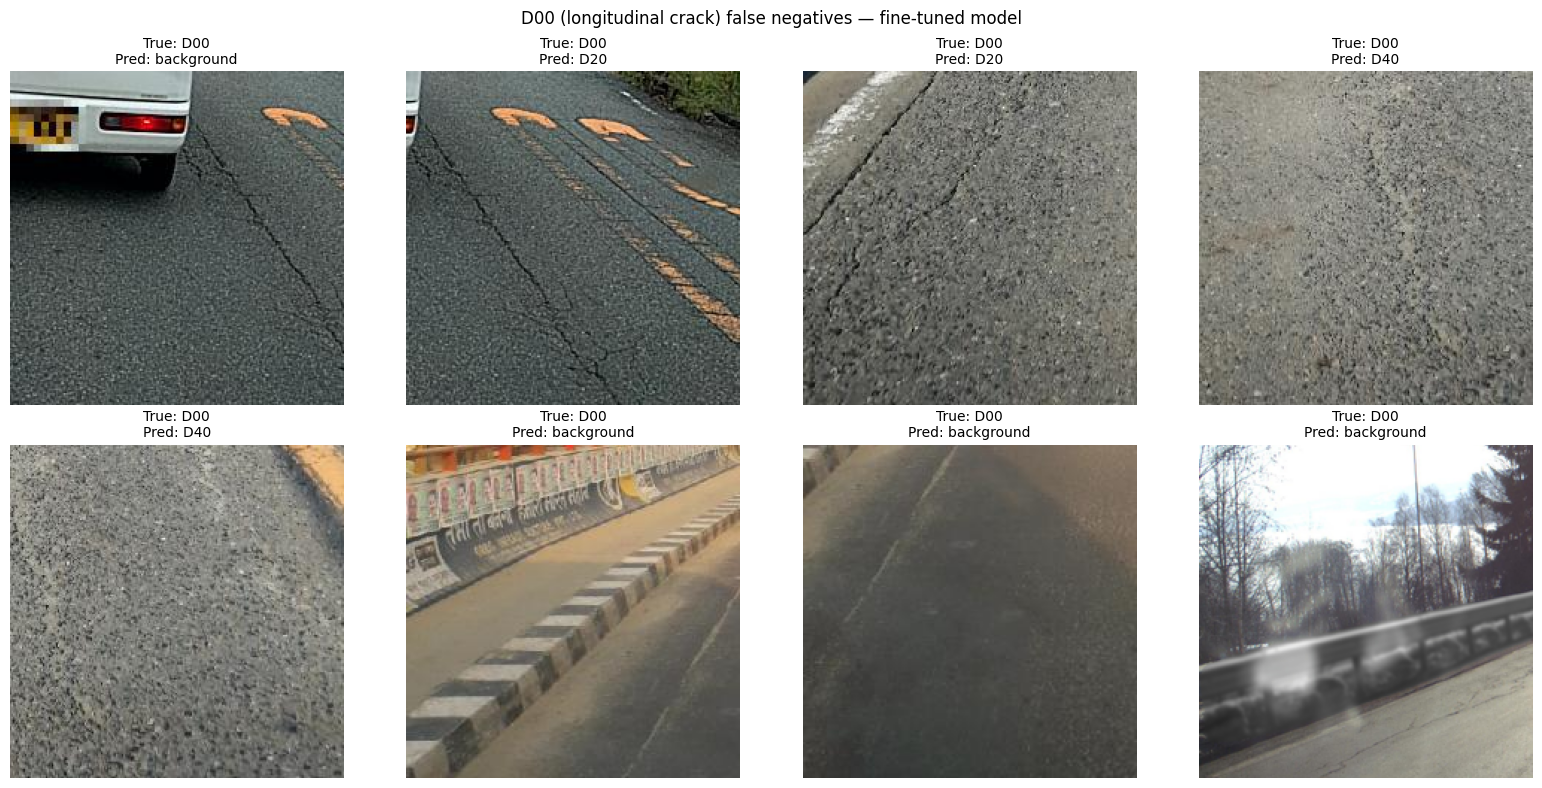

Saved: ./rdd_project/d00_false_negatives.png


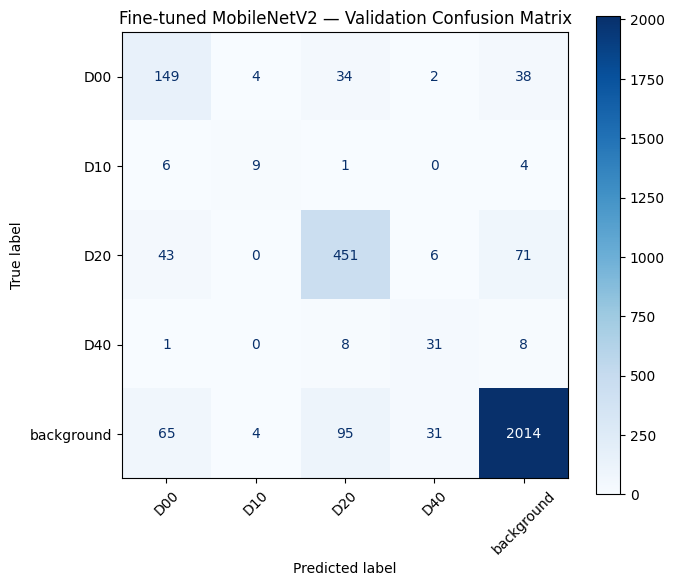


Saved: ./rdd_project/val_predictions_for_person4.parquet

BENCHMARK vs PARDESHI ET AL. (2025) — READ THE CAVEAT BELOW

CAVEAT (state this explicitly in the report, not just here):
  - Pardeshi et al.: 5 classes (4 damage + "other corruption"), INDIA ONLY,
    patches are clean crops FROM ground-truth boxes (not sliding-window),
    domain-specific self-supervised pretraining. Accuracy/weighted F1 = 78%.
  - Ours: 4 damage classes + background, ALL COUNTRIES IN THIS SAMPLE,
    sliding-window patches (noisier — can clip a crack's edge at IoU>=0.3
    and still count as positive), plain ImageNet init (no domain-specific
    pretraining).
  - These are NOT directly comparable numbers. Report macro F1 as the
    honest headline number, not weighted F1 alone (it sits deceptively
    close to Pardeshi's 78% without capturing per-class performance).

Model                            Macro F1   Weighted F1
Ours — fine-tuned                   0.665         0.867
Ours — frozen+RF               

In [22]:
# ============================================================
# BLOCK 6 — Evaluation, comparison, error analysis, benchmark table
# (rebuilt against val_patches_metadata.parquet — no separate .npz needed;
# reuses Block 3's shared get_transforms() / build_classifier_model())
# ============================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
import joblib

CLASSES = ["D00", "D10", "D20", "D40", "background"]

# ------------------------------------------------------------
# 1. Load ground truth + patch geometry — the canonical row order
# ------------------------------------------------------------
meta = pd.read_parquet(f"{BASE_DIR}/val_patches_metadata.parquet").reset_index(drop=True)
print(f"Loaded {len(meta)} val patches")

y_val = meta["class"].map(CLASSES.index).to_numpy()

eval_transform = get_transforms()  # reuse the shared module from Block 3 — don't redefine

def load_patch(row):
    """Recreate the exact patch this row describes: open src image, resize by
    the SAME scale used at dataset-build time, crop by patch_coords."""
    with Image.open(row["src_img_path"]) as im:
        im = im.convert("RGB")
        w, h = im.size
        scale = row["scale"]
        if scale != 1.0:
            im = im.resize((int(round(w * scale)), int(round(h * scale))), Image.LANCZOS)
        x0, y0, x1, y1 = row["patch_coords"]
        return im.crop((x0, y0, x1, y1))

# ------------------------------------------------------------
# 2. Re-run BOTH models over this exact canonical patch list
# ------------------------------------------------------------

# --- 2a. Fine-tuned model — use the actual shared builder from Block 3 ---
finetuned_model = build_classifier_model()
finetuned_model.load_state_dict(torch.load(f"{BASE_DIR}/best_primary_model.pth", map_location=device))
finetuned_model = finetuned_model.to(device).eval()

# --- 2b. Frozen backbone + RF ---
frozen_backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
frozen_backbone.classifier = nn.Identity()
frozen_backbone = frozen_backbone.to(device).eval()
rf = joblib.load(f"{BASE_DIR}/frozen_rf_model.joblib")

y_pred_ft = np.zeros(len(meta), dtype=int)
y_pred_rf = np.zeros(len(meta), dtype=int)
patches_cache = [None] * len(meta)  # kept for error-analysis visualization below

BATCH = 64
with torch.no_grad():
    for start in range(0, len(meta), BATCH):
        end = min(start + BATCH, len(meta))
        batch_rows = meta.iloc[start:end]
        batch_patches = [load_patch(r) for _, r in batch_rows.iterrows()]
        for i, p in enumerate(batch_patches):
            patches_cache[start + i] = p
        batch_tensor = torch.stack([eval_transform(p) for p in batch_patches]).to(device)

        ft_logits = finetuned_model(batch_tensor)
        y_pred_ft[start:end] = ft_logits.argmax(dim=1).cpu().numpy()

        rf_feats = frozen_backbone(batch_tensor).cpu().numpy()
        y_pred_rf[start:end] = rf.predict(rf_feats)

        if (start // BATCH) % 10 == 0:
            print(f"  {end}/{len(meta)}")

print("Inference complete.")

# ------------------------------------------------------------
# 3. Side-by-side overall comparison
# ------------------------------------------------------------
macro_ft = f1_score(y_val, y_pred_ft, average="macro")
macro_rf = f1_score(y_val, y_pred_rf, average="macro")
weighted_ft = f1_score(y_val, y_pred_ft, average="weighted")
weighted_rf = f1_score(y_val, y_pred_rf, average="weighted")

print("=" * 70)
print("OVERALL COMPARISON — FINE-TUNED vs FROZEN+RF")
print("=" * 70)
print(f"{'Metric':<15} {'Fine-tuned':>12} {'Frozen+RF':>12} {'Gap':>10}")
print(f"{'Macro F1':<15} {macro_ft:>12.4f} {macro_rf:>12.4f} {macro_ft-macro_rf:>10.4f}")
print(f"{'Weighted F1':<15} {weighted_ft:>12.4f} {weighted_rf:>12.4f} {weighted_ft-weighted_rf:>10.4f}")

report_ft = classification_report(y_val, y_pred_ft, target_names=CLASSES, output_dict=True, zero_division=0)
report_rf = classification_report(y_val, y_pred_rf, target_names=CLASSES, output_dict=True, zero_division=0)

print("\nPer-class F1 comparison:")
print(f"{'Class':<12} {'Fine-tuned':>12} {'Frozen+RF':>12} {'Support':>10}")
for cls in CLASSES:
    print(f"{cls:<12} {report_ft[cls]['f1-score']:>12.3f} {report_rf[cls]['f1-score']:>12.3f} "
          f"{int(report_ft[cls]['support']):>10}")

# ------------------------------------------------------------
# 4. Per-country breakdown — direct from the 'country' column
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("PER-COUNTRY MACRO F1 (fine-tuned model)")
print("=" * 70)
countries_arr = meta["country"].to_numpy()
for country in sorted(meta["country"].unique()):
    mask = countries_arr == country
    country_macro_f1 = f1_score(y_val[mask], y_pred_ft[mask], average="macro", zero_division=0)
    print(f"  {country:<15}: macro F1 = {country_macro_f1:.4f}  (n={mask.sum()})")

# ------------------------------------------------------------
# 5. Error analysis — D00 false negatives, fine-tuned model
# ------------------------------------------------------------
D00_idx = CLASSES.index("D00")
d00_missed_mask = (y_val == D00_idx) & (y_pred_ft != D00_idx)
d00_total = (y_val == D00_idx).sum()
d00_caught = ((y_val == D00_idx) & (y_pred_ft == D00_idx)).sum()
print(f"\nD00 recall (fine-tuned): {d00_caught} / {d00_total} caught")

missed_indices = np.where(d00_missed_mask)[0]
n_show = min(8, len(missed_indices))
if n_show > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i, idx in enumerate(missed_indices[:n_show]):
        axes[i].imshow(patches_cache[idx])
        axes[i].set_title(f"True: D00\nPred: {CLASSES[y_pred_ft[idx]]}", fontsize=10)
        axes[i].axis("off")
    for i in range(n_show, len(axes)):
        axes[i].axis("off")
    plt.suptitle("D00 (longitudinal crack) false negatives — fine-tuned model")
    plt.tight_layout()
    plt.savefig(f"{BASE_DIR}/d00_false_negatives.png", dpi=120)
    plt.show()
    print(f"Saved: {BASE_DIR}/d00_false_negatives.png")
else:
    print("No D00 false negatives to show.")

# ------------------------------------------------------------
# 6. Confusion matrix — fine-tuned model
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_ft, display_labels=CLASSES, ax=ax, cmap="Blues", xticks_rotation=45
)
ax.set_title("Fine-tuned MobileNetV2 — Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/confusion_matrix_finetuned.png", dpi=120)
plt.show()

# ------------------------------------------------------------
# 7. Save canonical predictions for Person 4 (patch coords + probabilities)
# ------------------------------------------------------------
out = meta[["img_id", "country", "patch_coords", "src_img_path", "scale"]].copy()
out["true_class"] = meta["class"]
out["pred_class_finetuned"] = [CLASSES[i] for i in y_pred_ft]
out["pred_class_frozen_rf"] = [CLASSES[i] for i in y_pred_rf]
out.to_parquet(f"{BASE_DIR}/val_predictions_for_person4.parquet")
print(f"\nSaved: {BASE_DIR}/val_predictions_for_person4.parquet")

# ------------------------------------------------------------
# 8. Benchmark table vs Pardeshi et al. — WITH THE CAVEAT STATED
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("BENCHMARK vs PARDESHI ET AL. (2025) — READ THE CAVEAT BELOW")
print("=" * 70)
print("""
CAVEAT (state this explicitly in the report, not just here):
  - Pardeshi et al.: 5 classes (4 damage + "other corruption"), INDIA ONLY,
    patches are clean crops FROM ground-truth boxes (not sliding-window),
    domain-specific self-supervised pretraining. Accuracy/weighted F1 = 78%.
  - Ours: 4 damage classes + background, ALL COUNTRIES IN THIS SAMPLE,
    sliding-window patches (noisier — can clip a crack's edge at IoU>=0.3
    and still count as positive), plain ImageNet init (no domain-specific
    pretraining).
  - These are NOT directly comparable numbers. Report macro F1 as the
    honest headline number, not weighted F1 alone (it sits deceptively
    close to Pardeshi's 78% without capturing per-class performance).
""")

print(f"{'Model':<30} {'Macro F1':>10} {'Weighted F1':>13}")
print(f"{'Ours — fine-tuned':<30} {macro_ft:>10.3f} {weighted_ft:>13.3f}")
print(f"{'Ours — frozen+RF':<30} {macro_rf:>10.3f} {weighted_rf:>13.3f}")
print(f"{'Pardeshi et al. (2025)':<30} {'—':>10} {0.780:>13.3f}  (India-only, 5-class, box-crops)")
print(f"{'CRDDC 2022 top team':<30} {'—':>10} {0.769:>13} (F1, DETECTION — not comparable to any row above)")